# Persona 2 - Recuperacion Clasica (TF-IDF y BM25)
### Proyecto Bimestre 1 - Recuperacion de Informacion

## 1. Importaciones y configuracion

In [95]:
import pandas as pd
import numpy as np
import nltk

In [96]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import defaultdict, Counter

In [97]:
import string
import math

In [98]:
# Descarga de recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\AdminPC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AdminPC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\AdminPC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 2. Carga del corpus
Se utiliza el dataset Reuters-21578 (ModApte split).  
Se eliminan las filas que no tienen texto.

In [99]:
# Cargar el dataset
df = pd.read_csv("../data/ModApte_test.csv")

# Eliminar documentos sin texto
df = df.dropna(subset=['text'])

print(f"Documentos cargados: {len(df)}")
print(f"Columnas disponibles: {df.columns.tolist()}")

Documentos cargados: 3023
Columnas disponibles: ['text', 'text_type', 'topics', 'lewis_split', 'cgis_split', 'old_id', 'new_id', 'places', 'people', 'orgs', 'exchanges', 'date', 'title']


In [100]:
df.head(3)

,text,text_type,topics,lewis_split,cgis_split,old_id,new_id,places,people,orgs,exchanges,date,title
0,Mounting trade friction between the\nU.S. And ...,"""NORM""",['trade'],"""TEST""","""TRAINING-SET""","""3809""","""14826""",['hong-kong' 'usa' 'japan' 'taiwan' 'malaysia'...,[],[],[],8-APR-1987 01:03:47.52,ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
1,A survey of 19 provinces and seven cities\nsho...,"""NORM""",['grain'],"""TEST""","""TRAINING-SET""","""3811""","""14828""",['china'],[],[],[],8-APR-1987 01:19:17.29,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STOCKS
2,The Ministry of International Trade and\nIndus...,"""NORM""",['crude' 'nat-gas'],"""TEST""","""TRAINING-SET""","""4356""","""14829""",['japan'],[],[],[],8-APR-1987 01:22:17.25,JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWARDS


In [101]:
df.tail(3)

,text,text_type,topics,lewis_split,cgis_split,old_id,new_id,places,people,orgs,exchanges,date,title
3296,The Japan/India-Pakistan-Gulf/Japan\nshipping ...,"""NORM""",['ship'],"""TEST""","""TRAINING-SET""","""19862""","""21574""",['hong-kong' 'japan' 'india' 'pakistan' 'iran'...,[],[],[],19-OCT-1987 00:34:08.94,JAPAN/INDIA CONFERENCE CUTS GULF WAR RISK CHARGES
3297,The Soviet Union's industrial output is\ngrowi...,"""NORM""",['ipi'],"""TEST""","""TRAINING-SET""","""19861""","""21575""",['ussr'],[],[],[],19-OCT-1987 00:18:22.79,SOVIET INDUSTRIAL GROWTH/TRADE SLOWER IN 1987
3298,Six black miners have been killed\nand two inj...,"""NORM""",['gold'],"""TEST""","""TRAINING-SET""","""19860""","""21576""",['south-africa'],[],[],[],19-OCT-1987 00:05:11.26,SIX KILLED IN SOUTH AFRICAN GOLD MINE ACCIDENT


## 3. Preprocesamiento
Se aplica a cada documento:
- Conversion a minusculas
- Tokenizacion
- Eliminacion de signos de puntuacion
- Eliminacion de stopwords en ingles
- Eliminacion de tokens cortos (menor a 3 caracteres)

In [102]:
# Cargar stopwords en ingles
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Convertir a minusculas
    text = text.lower()

    # Tokenizar el texto
    tokens = word_tokenize(text)

    # Limpiar tokens: eliminar puntuacion, stopwords y tokens cortos
    tokens = [
        t.replace('.', '').replace('-', ' ').strip()
        for t in tokens
        if t not in string.punctuation
        and t not in stop_words
        and len(t) > 2
    ]

    # Eliminar tokens vacios que quedaron tras el reemplazo
    tokens = [t for t in tokens if t]

    return tokens

# Verificar con el primer documento
print('Ejemplo de tokens del primer documento:')
print(preprocess(df['text'].iloc[0])[:20])

Ejemplo de tokens del primer documento:
['mounting', 'trade', 'friction', 'us', 'japan', 'raised', 'fears', 'among', 'many', 'asia', 'exporting', 'nations', 'row', 'could', 'inflict', 'far reaching', 'economic', 'damage', 'businessmen', 'officials']


## 4. Indice invertido y estadisticas
Se construyen estructuras para recuperacion clasica:
- indice invertido (termino -> {doc_id: frecuencia})
- frecuencia de documento (df)
- longitud de documento y promedio

In [103]:
# Tokenizar todos los documentos
df['tokens'] = df['text'].apply(preprocess)

In [104]:
# Construccion del indice invertido
# termino -> {doc_id: frecuencia}
inverted_index = defaultdict(dict)
doc_len = {}

for i, tokens in enumerate(df['tokens']):
    term_counts = Counter(tokens)
    doc_len[i] = sum(term_counts.values())
    for term, freq in term_counts.items():
        inverted_index[term][i] = freq

doc_freq = {term: len(postings) for term, postings in inverted_index.items()}
N = len(df)
avg_doc_len = sum(doc_len.values()) / N

print(f'Documentos indexados: {N}')
print(f'Terminos en vocabulario: {len(inverted_index)}')
print(f'Longitud promedio de documento: {avg_doc_len:.2f} tokens')

Documentos indexados: 3023
Terminos en vocabulario: 23141
Longitud promedio de documento: 81.89 tokens


In [105]:
# Verificar estructura del indice invertido
# Para cada termino: documentos en los que aparece + frecuencia
sample_terms = list(inverted_index.keys())[:10]

rows = []
for term in sample_terms:
    postings = inverted_index[term]
    df_t = doc_freq[term]
    for doc_id, freq in list(postings.items())[:3]:
        rows.append({'termino': term, 'doc_id': doc_id, 'frecuencia': freq, 'df (docs con termino)': df_t})

pd.DataFrame(rows)

,termino,doc_id,frecuencia,df (docs con termino)
0,mounting,0,1,7
1,mounting,316,1,7
2,mounting,319,1,7
3,trade,0,15,290
4,trade,2,1,290
5,trade,3,1,290
6,friction,0,1,9
7,friction,22,1,9
8,friction,282,1,9
9,us,0,17,571


## 5. Modelos clasicos de recuperacion
Se implementan dos modelos:
- TF-IDF + similitud coseno
- BM25

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [107]:
# Vectorizar usando tokens preprocesados (mismos que el indice invertido)
corpus = df['tokens'].apply(lambda tokens: ' '.join(tokens)).tolist()

vectorizer = TfidfVectorizer()
matriz_tfidf = vectorizer.fit_transform(corpus)

print(f"Forma de la matriz TF-IDF: {matriz_tfidf.shape}")
print(f"  {matriz_tfidf.shape[0]} documentos x {matriz_tfidf.shape[1]} terminos")

table = pd.DataFrame(
    matriz_tfidf.toarray(),
    index=[f"doc{i+1}" for i in range(matriz_tfidf.shape[0])],
    columns=vectorizer.get_feature_names_out()
)

print(table.head(10))

Forma de la matriz TF-IDF: (3023, 18286)
  3023 documentos x 18286 terminos
        00      000  0000  0006  0007200  0008  0009  001  002  0027  ...  \
doc1   0.0  0.00000   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   
doc2   0.0  0.00000   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   
doc3   0.0  0.00000   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   
doc4   0.0  0.00000   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   
doc5   0.0  0.00000   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   
doc6   0.0  0.00000   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   
doc7   0.0  0.00000   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   
doc8   0.0  0.00000   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   
doc9   0.0  0.08363   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   
doc10  0.0  0.00000   0.0   0.0      0.0   0.0   0.0  0.0  0.0   0.0  ...   

       zloties  zoete  zollinger  zondervan  zone  zones  zoran  zuheir  \
d

In [108]:
from sklearn.metrics.pairwise import cosine_similarity

def search_tfidf_cosine(query, top_k=10):
    # Preprocesar la consulta con el mismo pipeline del corpus
    query_tokens = preprocess(query)
    query_text = ' '.join(query_tokens)

    # Vectorizar la consulta usando el mismo vectorizer entrenado en el corpus
    query_vector = vectorizer.transform([query_text])

    # Calcular similitud coseno entre la consulta y todos los documentos
    similitudes = cosine_similarity(query_vector, matriz_tfidf).flatten()

    # Crear ranking ordenado por similitud descendente (solo docs con score > 0)
    ranking = sorted(enumerate(similitudes), key=lambda x: x[1], reverse=True)
    return [(indice_doc, score) for indice_doc, score in ranking[:top_k] if score > 0]

def search_bm25(query, top_k=10, k1=1.5, b=0.75):
    query_tokens = preprocess(query)
    frecuencia_query = Counter(query_tokens)
    scores = defaultdict(float)

    for termino, freq_en_query in frecuencia_query.items():
        postings = inverted_index.get(termino)
        if not postings:
            continue
        frecuencia_documento = doc_freq[termino]
        idf = math.log(1.0 + ((N - frecuencia_documento + 0.5) / (frecuencia_documento + 0.5)))
        for indice_doc, freq_en_doc in postings.items():
            longitud_doc = doc_len[indice_doc]
            denominador = freq_en_doc + k1 * (1.0 - b + b * (longitud_doc / avg_doc_len))
            scores[indice_doc] += idf * ((freq_en_doc * (k1 + 1.0)) / denominador)

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

In [109]:
def search_jaccard(query, top_k=10):
    # Preprocesar la consulta
    query_tokens = set(preprocess(query))

    if not query_tokens:
        return []

    scores = {}

    for indice_doc, tokens in enumerate(df['tokens']):
        conjunto_documento = set(tokens)

        # Similitud Jaccard = |interseccion| / |union|
        interseccion = query_tokens & conjunto_documento
        union = query_tokens | conjunto_documento

        if len(union) > 0:
            similitud = len(interseccion) / len(union)
            if similitud > 0:
                scores[indice_doc] = similitud

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

## 6. Consulta de texto libre y ranking
Se ejecuta una consulta y se muestran los resultados ordenados por relevancia.

In [110]:
def show_results(ranked_docs, model_name='Modelo', top_n=5):
    print(f'\n[{model_name}] Top {min(top_n, len(ranked_docs))} resultados')

    if not ranked_docs:
        print('No se encontraron resultados.')
        return

    for rank, (doc_id, score) in enumerate(ranked_docs[:top_n], start=1):
        row = df.iloc[doc_id]
        title = str(row['title']) if pd.notna(row['title']) else ''
        text = str(row['text']).replace('\n', ' ')
        snippet = text[:140] + ('...' if len(text) > 140 else '')

        print(f'{rank}. idx={doc_id} | score={score:.5f}')
        if title:
            print(f'   title: {title}')
        print(f'   text : {snippet}')

query = 'trade japan market'

tfidf_results  = search_tfidf_cosine(query, top_k=10)
bm25_results   = search_bm25(query, top_k=10)
jaccard_results = search_jaccard(query, top_k=10)

print(f'Consulta: {query}')

Consulta: trade japan market


In [111]:
show_results(tfidf_results,   model_name='TF-IDF + Coseno', top_n=5)


[TF-IDF + Coseno] Top 5 resultados
1. idx=319 | score=0.41623
   title: JAPAN MINISTRY HAS NO COMMENT ON RICE TALKS REPORT
   text : The Agriculture Ministry declined comment on a local newspaper report that Japan had agreed to hold talks on its closed rice market in the n...
2. idx=0 | score=0.37167
   title: ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
   text : Mounting trade friction between the U.S. And Japan has raised fears among many of Asia's exporting nations that the row could inflict far-re...
3. idx=18 | score=0.36614
   title: JAPAN MINISTRY SAYS OPEN FARM TRADE WOULD HIT U.S.
   text : Japan's Agriculture Ministry, angered by U.S. Demands that Japan open its farm products market, will tell U.S. Officials at talks later this...
4. idx=1224 | score=0.35485
   title: REAGAN TO ANNOUNCE DECISION ON JAPAN SANCTIONS
   text : President Reagan today is to announce a decision on tough new tariffs on Japanese exports to retaliate for what he calls Japan's failure to ...
5. i

In [112]:
show_results(bm25_results,    model_name='BM25', top_n=5)


[BM25] Top 5 resultados
1. idx=319 | score=11.64866
   title: JAPAN MINISTRY HAS NO COMMENT ON RICE TALKS REPORT
   text : The Agriculture Ministry declined comment on a local newspaper report that Japan had agreed to hold talks on its closed rice market in the n...
2. idx=1203 | score=11.49196
   title: U.S. URGES JAPAN TO OPEN FARM MARKET FURTHER
   text : U.S. Agriculture Secretary Richard Lyng has asked Japan to open its farm market further to help Washington cut its trade deficit and ease pr...
3. idx=1222 | score=11.49196
   title: U.S. URGES JAPAN TO OPEN FARM MARKET FURTHER
   text : U.S. Agriculture Secretary Richard Lyng has asked Japan to open its farm market further to help Washington cut its trade deficit and ease pr...
4. idx=889 | score=10.88756
   title: TRADE ISSUES STRAINING EC'S PATIENCE WITH JAPAN
   text : Member states of the European Community are starting to run out of patience with Japan which they believe has repeatedly promised major init...
5. idx=18 | scor

In [113]:
show_results(jaccard_results, model_name='Jaccard', top_n=5)


[Jaccard] Top 5 resultados
1. idx=568 | score=0.12500
   title: JAPAN BUYS 5,000 TONNES CANADIAN RAPESEED
   text : Japan bought 5,000 tonnes Canadian rapeseed overnight at an undisclosed price for May shipment, trade sources said.  Reuter 
2. idx=181 | score=0.10526
   title: JAPAN BUYS 4,000 TONNES CANADIAN RAPESEED
   text : Japan bought 4,000 tonnes of Canadian rapeseed overnight at an undisclosed price for last half May/first half June shipment, trade sources s...
3. idx=1190 | score=0.07692
   title: BANK OF JAPAN INTERVENES IN TOKYO AFTER OPENING
   text : The Bank of Japan intervened in Tokyo to buy dollars just after the market opened, dealers said.     The dollar opened at 142.05 yen against...
4. idx=411 | score=0.06667
   title: ROPAK &lt;ROPK> FORMS JAPANESE UNIT
   text : Ropak corp said it has formed a new Tokyo-based subsidiary called Ropak Nippon Ltd to market its North American products in Japan.     It sa...
5. idx=2262 | score=0.06667
   title: GOODYEAR &lt;GT> TO 

## 7. Evaluacion de resultados
Se usan los topics del corpus como qrels:
- Cada topic unico es una consulta de prueba
- Documentos relevantes = todos los docs que contienen ese topic
- Metricas: Precision@k, Recall@k y MAP

In [114]:
import re

# Construir qrels: topic -> conjunto de indices de documentos relevantes
# Los topics tienen formato numpy: ['crude' 'nat-gas'] (sin coma entre items)
# Solucion: regex para extraer cada string entre comillas individualmente
qrels = defaultdict(set)

for i, row in df.iterrows():
    valor_topics = row['topics']
    if pd.isna(valor_topics):
        continue
    # Extraer todos los strings entre comillas simples
    lista_topics = re.findall(r"'([^']+)'", str(valor_topics))
    for topic in lista_topics:
        topic = topic.strip()
        if topic:
            qrels[topic].add(df.index.get_loc(i))

# Solo topics con al menos 2 documentos relevantes
qrels = {topic: docs for topic, docs in qrels.items() if len(docs) >= 2}

print(f"Topics usados como consultas: {len(qrels)}")
print(f"Ejemplo de topics: {list(qrels.keys())[:10]}")
print(f"Docs relevantes para 'trade': {len(qrels.get('trade', set()))}")
print(f"Docs relevantes para 'crude': {len(qrels.get('crude', set()))}")
print(f"Docs relevantes para 'nat-gas': {len(qrels.get('nat-gas', set()))}")

Topics usados como consultas: 75
Ejemplo de topics: ['trade', 'grain', 'crude', 'nat-gas', 'rice', 'corn', 'sugar', 'tin', 'rubber', 'veg-oil']
Docs relevantes para 'trade': 113
Docs relevantes para 'crude': 164
Docs relevantes para 'nat-gas': 29


In [115]:
def precision_at_k(ranked_docs, relevant_docs, k):
    """Fraccion de documentos relevantes en los primeros k resultados."""
    top_k = [doc_id for doc_id, _ in ranked_docs[:k]]
    hits = sum(1 for doc_id in top_k if doc_id in relevant_docs)
    return hits / k if k > 0 else 0.0


def recall_at_k(ranked_docs, relevant_docs, k):
    """Fraccion de relevantes recuperados en los primeros k resultados."""
    top_k = [doc_id for doc_id, _ in ranked_docs[:k]]
    hits = sum(1 for doc_id in top_k if doc_id in relevant_docs)
    return hits / len(relevant_docs) if len(relevant_docs) > 0 else 0.0


def average_precision(ranked_docs, relevant_docs):
    """Average Precision para una sola consulta."""
    if not relevant_docs:
        return 0.0
    hits = 0
    precision_sum = 0.0
    for rank, (doc_id, _) in enumerate(ranked_docs, start=1):
        if doc_id in relevant_docs:
            hits += 1
            precision_sum += hits / rank
    return precision_sum / len(relevant_docs)


def evaluar_modelo(search_fn, qrels, k=10):
    """
    Evalua un modelo sobre todas las consultas en qrels.
    Retorna Precision@k, Recall@k y MAP promedio.
    """
    precision_scores = []
    recall_scores = []
    ap_scores = []

    for topic, relevant_docs in qrels.items():
        ranked_docs = search_fn(topic, top_k=k)
        precision_scores.append(precision_at_k(ranked_docs, relevant_docs, k))
        recall_scores.append(recall_at_k(ranked_docs, relevant_docs, k))
        ap_scores.append(average_precision(ranked_docs, relevant_docs))

    return {
        f'Precision@{k}': round(sum(precision_scores) / len(precision_scores), 4),
        f'Recall@{k}':    round(sum(recall_scores)    / len(recall_scores),    4),
        'MAP':            round(sum(ap_scores)         / len(ap_scores),        4),
    }

print("Funciones de evaluacion listas.")

Funciones de evaluacion listas.


In [116]:
# Evaluar los tres modelos con k=10
K = 10

print(f"Evaluando modelos con {len(qrels)} consultas (topics) y k={K}...")
print("Esto puede tardar unos segundos (Jaccard itera sobre todo el corpus).\n")

resultados_tfidf   = evaluar_modelo(search_tfidf_cosine, qrels, k=K)
resultados_bm25    = evaluar_modelo(search_bm25,         qrels, k=K)
resultados_jaccard = evaluar_modelo(search_jaccard,      qrels, k=K)

# Tabla comparativa
tabla_evaluacion = pd.DataFrame(
    [resultados_tfidf, resultados_bm25, resultados_jaccard],
    index=['TF-IDF + Coseno', 'BM25', 'Jaccard']
)

print("=== Comparacion de modelos ===")
print(tabla_evaluacion.to_string())
tabla_evaluacion

Evaluando modelos con 75 consultas (topics) y k=10...
Esto puede tardar unos segundos (Jaccard itera sobre todo el corpus).

=== Comparacion de modelos ===
                 Precision@10  Recall@10     MAP
TF-IDF + Coseno        0.4147     0.3286  0.2770
BM25                   0.3480     0.2735  0.2443
Jaccard                0.3093     0.2545  0.1980


,Precision@10,Recall@10,MAP
TF-IDF + Coseno,0.4147,0.3286,0.2770
BM25,0.3480,0.2735,0.2443
Jaccard,0.3093,0.2545,0.1980


## 8. Recuperación semántica con Embeddings
Se utiliza un modelo preentrenado (`all-MiniLM-L6-v2`) de `sentence-transformers` para generar embeddings densos.  
Los vectores se almacenan en **ChromaDB** para búsqueda eficiente por similitud coseno.

In [117]:
from sentence_transformers import SentenceTransformer
import chromadb

# Modelo ligero y eficaz para recuperacion semantica
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'
embedder = SentenceTransformer(EMBEDDING_MODEL)

print(f"Modelo cargado: {EMBEDDING_MODEL}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5975.29it/s]


Modelo cargado: all-MiniLM-L6-v2


In [118]:
# Generar embeddings para todos los documentos del corpus
# Se usa el texto original (no tokenizado) para aprovechar el contexto del modelo
print("Generando embeddings para el corpus (puede tardar ~1-2 min)...")

corpus_texts = df['text'].tolist()
doc_embeddings = embedder.encode(
    corpus_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(f"\nEmbeddings generados: {doc_embeddings.shape}")
print(f"  {doc_embeddings.shape[0]} documentos x {doc_embeddings.shape[1]} dimensiones")

Generando embeddings para el corpus (puede tardar ~1-2 min)...


Batches: 100%|██████████| 48/48 [01:21<00:00,  1.70s/it]


Embeddings generados: (3023, 384)
  3023 documentos x 384 dimensiones


In [119]:
# Crear coleccion ChromaDB en memoria
chroma_client = chromadb.Client()

# Eliminar coleccion si existe (re-ejecucion del notebook)
try:
    chroma_client.delete_collection("reuters_corpus")
except:
    pass

collection = chroma_client.create_collection(
    name="reuters_corpus",
    metadata={"hnsw:space": "cosine"}
)

# Insertar documentos en lotes (ChromaDB tiene limite por batch)
BATCH_SIZE = 500
ids     = [str(i) for i in range(len(df))]
docs    = corpus_texts
embeds  = doc_embeddings.tolist()

for start in range(0, len(ids), BATCH_SIZE):
    end = min(start + BATCH_SIZE, len(ids))
    collection.add(
        ids=ids[start:end],
        documents=docs[start:end],
        embeddings=embeds[start:end]
    )

print(f"ChromaDB: {collection.count()} documentos indexados")

ChromaDB: 3023 documentos indexados


In [120]:
def search_embeddings(query, top_k=10):
    """Busqueda semantica usando ChromaDB + sentence-transformers."""
    query_embedding = embedder.encode([query], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=top_k
    )
    # Distancia coseno ChromaDB: 0 = identico, 2 = opuesto
    # Convertir a similitud: score = 1 - distancia
    doc_ids    = [int(i) for i in results['ids'][0]]
    distances  = results['distances'][0]
    scores     = [1.0 - d for d in distances]
    return list(zip(doc_ids, scores))

# Prueba rapida
query_test = 'trade japan market'
emb_results = search_embeddings(query_test, top_k=10)
show_results(emb_results, model_name='Embeddings (ChromaDB)', top_n=5)


[Embeddings (ChromaDB)] Top 5 resultados
1. idx=18 | score=0.63531
   title: JAPAN MINISTRY SAYS OPEN FARM TRADE WOULD HIT U.S.
   text : Japan's Agriculture Ministry, angered by U.S. Demands that Japan open its farm products market, will tell U.S. Officials at talks later this...
2. idx=1553 | score=0.62626
   title: JAPAN CONCERNED AT EC TRADE THREATS - MINISTER
   text : Japan is disappointed at the recent threats of trade retaliation from the European Community (EC) just as the trade situation between the tw...
3. idx=1202 | score=0.62156
   title: SAUDI ARABIA WANTS TO INCREASE OIL SALES TO JAPAN
   text : Saudi Arabia hopes to increase the volume of its oil exports to Japan through expanding bilateral trade, Saudi Arabian Interior Minister Nai...
4. idx=851 | score=0.59830
   title: CURRENCY MOVES MAY BE HURTING WORLD TRADE
   text : Japanese trade figures are seriously challenging the entrenched view of policy makers of the Group of Seven industrialised nations that rela...
5. 

In [121]:
# Evaluar modelo de embeddings con las mismas metricas y qrels
print("Evaluando modelo de embeddings...")
resultados_emb = evaluar_modelo(search_embeddings, qrels, k=K)
print(f"Embeddings: {resultados_emb}")

Evaluando modelo de embeddings...
Embeddings: {'Precision@10': 0.3947, 'Recall@10': 0.2848, 'MAP': 0.2274}


## 9. Comparación de todos los modelos
Se comparan los cuatro modelos de recuperación:
- **Jaccard** — similitud binaria por conjuntos
- **TF-IDF + Coseno** — modelo vectorial clásico
- **BM25** — modelo probabilístico con normalización de longitud
- **Embeddings semánticos** — representación densa con modelo preentrenado + ChromaDB

In [122]:
# Tabla comparativa de los 4 modelos
tabla_final = pd.DataFrame(
    [resultados_jaccard, resultados_tfidf, resultados_bm25, resultados_emb],
    index=['Jaccard', 'TF-IDF + Coseno', 'BM25', 'Embeddings (ChromaDB)']
)

print(f"=== Comparacion final de modelos (k={K}, {len(qrels)} consultas) ===")
print(tabla_final.to_string())
tabla_final

=== Comparacion final de modelos (k=10, 75 consultas) ===
                       Precision@10  Recall@10     MAP
Jaccard                      0.3093     0.2545  0.1980
TF-IDF + Coseno              0.4147     0.3286  0.2770
BM25                         0.3480     0.2735  0.2443
Embeddings (ChromaDB)        0.3947     0.2848  0.2274


,Precision@10,Recall@10,MAP
Jaccard,0.3093,0.2545,0.1980
TF-IDF + Coseno,0.4147,0.3286,0.2770
BM25,0.3480,0.2735,0.2443
Embeddings (ChromaDB),0.3947,0.2848,0.2274


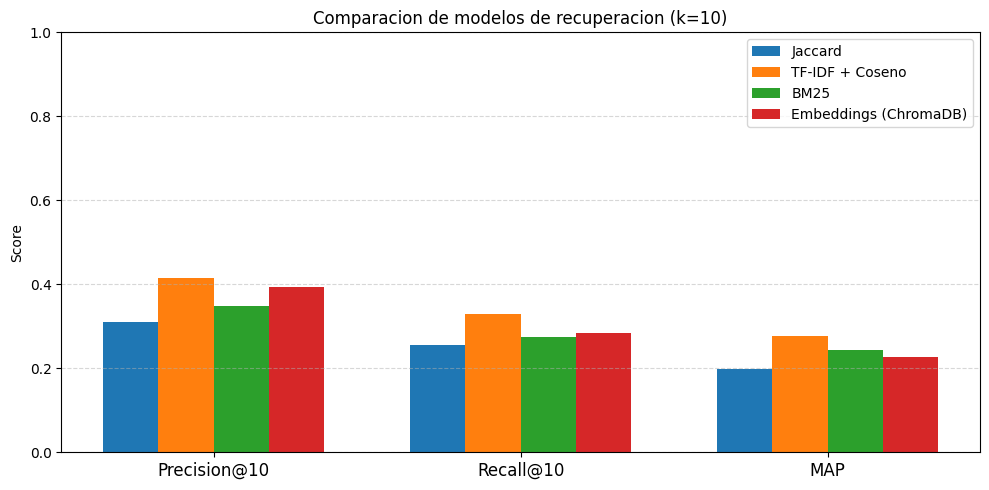

In [123]:
import matplotlib.pyplot as plt

# Grafico de barras comparativo
metricas = [f'Precision@{K}', f'Recall@{K}', 'MAP']
modelos  = tabla_final.index.tolist()
x = np.arange(len(metricas))
ancho = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, modelo in enumerate(modelos):
    vals = [tabla_final.loc[modelo, m] for m in metricas]
    ax.bar(x + i * ancho, vals, ancho, label=modelo)

ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylabel('Score')
ax.set_title(f'Comparacion de modelos de recuperacion (k={K})')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Análisis de resultados

**Observaciones esperadas:**
- **TF-IDF + Coseno** y **BM25** destacan en consultas de términos exactos del corpus (palabras clave del dominio financiero/noticias Reuters).
- **Embeddings semánticos** capturan paráfrasis y sinónimos que los modelos léxicos ignoran (ej. "oil price drop" → recupera docs sobre "petroleum cost decrease").
- **Jaccard** es el modelo más débil al no ponderar frecuencias ni contexto semántico.
- Los embeddings pueden fallar cuando los *topics* del qrel son términos muy específicos del dominio (ej. `nat-gas`, `veg-oil`) que el modelo preentrenado no asocia directamente.